<!--- Made by:
      Oscar Antonio Restrepo Gutiérrez
--->

# Root-finding methods
There are countless problems in physics where you need to find the roots of an equation (the values at which the function equals zero); finding the roots of polynomials is relatively easy (thanks to the fundamental theorem of algebra), but if there are transcendental functions then only numerical methods can be used. The methods studied here are,

1. [The graphical method: Introduction](#Introduccion).
2. [The bisection method](#El_metodo_de_la_biseccion).
3. [The fixed-point method](#punto_fijo).
4. [The Newton-Raphson method](#Newton-Raphson).
5. [The secant method](#Metodo_de_la_secante).
6. [The false-position method](#Metodo_de_la_posicion_falsa).
7. [Steffensen's method](#Metodo_de_Steffensen).

Finally, at the end of the chapter we have,

8. [Exercises](#Ejercicios).
9. [Supplementary material](#Material_complementario).

<!---
1) Bisection algorithm    (2.1 The Bisection Method pag 48).  
2) Fixed-point algorithm      (2.2 Fixed-Point Iteration 56).<br>
3) Newton-Raphson algorithm  (2.3 Newton’s Method and Its Extensions, pag 67).<br>
4) Secant algorithm       (2.3 Newton’s Method and Its Extensions, pag 71).<br> 
5) False-position algorithm  (2.3 Newton’s Method and Its Extensions, pag 73.<br>
6) Steffensen algorithm.
--->

<a id='Introduccion'></a>
## 1) The graphical method: Introduction
Consider the following physics problem: there is a radioactive gas inside a container that lets particles migrate out at a constant rate $v$ (for example through a leak). If at time $t$ there are $N(t)$ particles decaying at a constant rate $\lambda$, then this gas is governed by the differential equation,
  $$\frac{dN(t)}{dt}= -\lambda N(t) - v,$$
the analytical solution to this problem is given by
  $$N(t)=N_0e^{-\lambda t}+\frac{v}{\lambda}(e^{-\lambda t}-1)$$
where $N_0$ is the initial number of particles. Suppose $N_0=10000$ and that at time $t=1\,$ ms the number of particles is reduced by half, $N=5000$; if the migration rate is $v=1$ particle per ms, what is the decay rate $\lambda$ of the radioactive particles? Substituting into the equation above we get,
  $$5000=10000e^{-\lambda}+\frac{1}{\lambda}(e^{-\lambda}-1)$$
This defines a transcendental equation with no possible analytical solution — how do we solve the problem then?
The following code shows the plot of

$$f(\lambda)=10000e^{-\lambda}+\frac{1}{\lambda}(e^{-\lambda}-1) -5000$$

in which the value of $\lambda$ is obtained when the function crosses the $x$ axis, i.e. $f(\lambda)=0$:


In [1]:
import numpy as np
import matplotlib.pyplot as plt


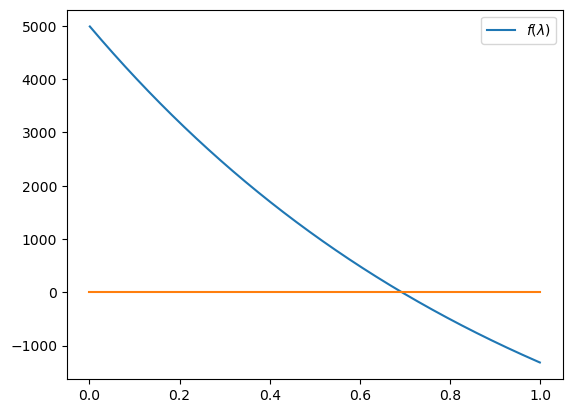

In [2]:
# radioactive decay function in a leaking flask (first problem)
f = lambda x: 1e4*np.exp(-x) + 1/x*(np.exp(-x)-1) - 5000
x=np.arange(0.001,1, 0.001) # values of lambda

plt.plot(x,f(x),label=r'$f(\lambda$)')    
plt.plot([0,1],[0,0]) # straight line at zero.
plt.legend()          # to show the labels. 

plt.show()


<a id='Ecuaciones_de_una_variable'></a>
### Single-variable equations
The previous question defines the problem of finding the roots of a single-variable function that is not a polynomial. By the fundamental theorem of algebra we know that every polynomial of degree $n$ has at most $n$ real or complex roots; in that case an analytical solution exists, but in cases like the introductory problem no analytical solution exists — these kinds of equations are known as transcendental. There are many classes of transcendental functions, for example:

   > a)  $f(x) =  x - \cos(x)$<br>
   > b)  $f(x) =  \tan(x) -x^2 + 2$<br>
   > c)  $f(x) =  0.10*\exp(x/5.0) + 5.0(\exp(x/5.0) - 1.2)$<br>

In these cases the roots can only be found approximately. There are several ways to find roots; the easiest is graphically, for example,

   $$f(x) = 0 = x - \cos(x)$$   
   $$x = \cos(x)$$

so you plot $x$ and then $\cos(x)$; the intersection point of the plots gives the root, ~0.73:


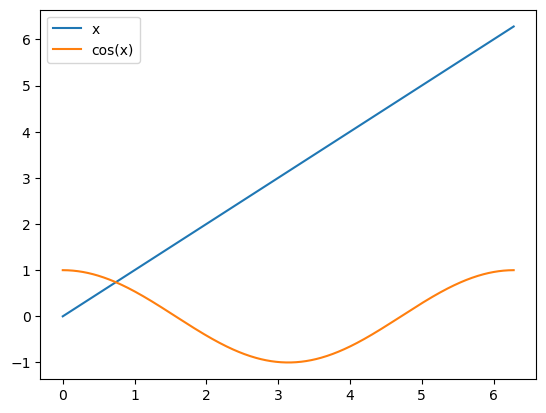

In [3]:
# %pylab, # 
# %matplotlib inline
#%matplotlib
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0,2*np.pi,0.01)
plt.plot(x,x, label="x")       # plot of x
plt.plot(x,np.cos(x),label='cos(x)') # plot of cos(x)
plt.legend() # to show the labels. 

plt.show()


This method is not very precise; note that the spacing in x is ~0.1,
but by using the zoom in the plot window we can get a first approximation of the root (or roots of the function); so from the plot we can get a first approximation with about 2 or 3 significant figures.
Likewise, for the radioactive decay case we see the root is where $f(\lambda)=0$; from the first plot we see $\lambda\approx 0.7$.

To find the roots with a better approximation there are several methods:


<a id='El_metodo_de_la_biseccion'></a>
## 2) The bisection method
 It's based on the intermediate value theorem, which states:
 
 If $f$ belongs to C$[a,b]$ (functions continuous on $[a,b]$) and $K$ is a number between $f(a)$ and $f(b)$, then there exists a number $c$ in $(a,b)$ such that $K = f(c)$.

 The method consists of selecting an interval $(a,b)$ that contains the root,
 note that $f(a)*f(b)<0$.
 Steps:

 1) Compute the midpoint of the interval and evaluate the function there:
   
   $$p = a + (b-a)/2 = (a+b)/2$$
 
 2) If $f(a)*f(p)>0$ then the root is in the interval $(p,b)$; we change $a = p$.<br>
 If $f(a)*f(p)<0$ then the root is in the interval $(a,p)$; we change $b = p$.
 
 3) Repeat the steps until any of these conditions holds:

   * $|p_n - p_{n-1}| < eps$,     (absolute error).
   
   * $|p_n - p_{n-1}|/|p_n|  < eps$, (percentage error, perhaps the best criterion).

   * $|f(p_n)| < eps$.           

The following plot shows convergence over three steps

|<img src="../figures/Bisection.png" alt="Drawing" style="width: 700px;"/>|
|:--:| 
| *Figure: Bisection method*, showing the successive approximations $p_1$, $p_2$, and $p_3$, their projections onto the function $y=f(x)$, and the corresponding nested intervals.|

In general $|\epsilon-\epsilon'|$ is defined as the absolute error and $|\epsilon-\epsilon'|/|\epsilon|$ is the relative error, where $\epsilon$ is the true value and $\epsilon'$ the approximate value; nevertheless, in the cases above, $p_n$ is taken as the "true" value, since it is a better approximation to $p$ than $p_{n-1}$. Any of the three criteria can run into problems; for example, we know that if $f(p) = 0$ the root has already been found, but there will be functions for which $f(p_n) < eps$ and $|p_n - p| >> eps$, i.e. $p$ is far from the root.

 
The python code for the bisection algorithm is:


In [4]:
import numpy as np

# define the bisection algorithm
def Biseccion(f,a,b,eps):
   if (f(a)*f(b) > 0.0): 
     print("choose a better interval")
     return
   
   a1 = a                # initial values a and b
   b1 = b                # obtained from the plot 
   i = 0                 # iteration counter
   while True:
     i=i+1
     p = (a1 + b1)*.5    # midpoint between a and b
     print (i, p, f(p))  

     if (f(a1)*f(p) > 0.0): a1 = p 
     if (f(a1)*f(p) < 0.0): b1 = p

     if ( np.abs(f(p)) < eps ):break # stopping condition.


**Example 1**: Let's find the root of $f(x)=\cos(x)-x$, on $[0,1]$:  


In [5]:
Biseccion(lambda x: np.cos(x) -x,0,1.0, 1.0e-10)

# note the function could also have been defined as 

# def f1(x):
#    return cos(x)

# and then used as:
# Biseccion(f1 ,0,1.0, 1.0e-10)


1 0.5 0.37758256189037276
2 0.75 -0.018311131126179103
3 0.625 0.18596311950521793
4 0.6875 0.0853349461524715
5 0.71875 0.03387937241806649
6 0.734375 0.00787472545850132
7 0.7421875 -0.005195711743759213
8 0.73828125 0.001345149751805108
9 0.740234375 -0.001923872780897673
10 0.7392578125 -0.0002890091467900868
11 0.73876953125 0.0005281584336581657
12 0.739013671875 0.00011959667132188656
13 0.7391357421875 -8.470073137478717e-05
14 0.73907470703125 1.7449346639941687e-05
15 0.739105224609375 -3.362534821038654e-05
16 0.7390899658203125 -8.087914744714375e-06
17 0.7390823364257812 4.680737457851691e-06
18 0.7390861511230469 -1.7035832658995886e-06
19 0.7390842437744141 1.488578440400623e-06
20 0.7390851974487305 -1.0750207668497325e-07
21 0.7390847206115723 6.905382659017079e-07
22 0.7390849590301514 2.915181156470936e-07
23 0.7390850782394409 9.200802475461956e-08
24 0.7390851378440857 -7.747024688420368e-09
25 0.7390851080417633 4.213050031065535e-08
26 0.7390851229429245 1.719173

**Exercise**: Plot and find the root of $f(x)=\tan(x)-x^2$ on $[1.55, 165]$. Why does it give an infinite loop?


In [6]:
# Biseccion(lambda x: np.tan(x) -x**2.0,1.55,1.65, 1.0e-10)
# IMPORTANT: to stop the loop, in Kernel select interrupt!


The error of the bisection method can be computed from
$$|p - p_n| = (b-a)/2^n$$
(for all $n>=1$), which means that,
$$p_n = p + O(1/2^n).$$
The notation $O(1/2^n)$ means an error of order $1/2^n$.

Finally, for the bisection method to work you must guarantee $f(a)f(b)<0$, though there will be cases where this doesn't hold; for example for the function $f(x) =(x-2)^2$, the bisection method won't work for any interval $[a,b]$, but the fixed-point method explained below can be used.

<a id='punto_fijo'></a>
## 3) The fixed-point method
A fixed point is a number for which the value of a function equals the same number when the function is evaluated there; in other words:

### Definition
For a given function $g(x)$, a number $p$ is a fixed point if,

$$g(p) = p.$$

It can be seen that if,

$$f(x) = x - g(x)$$

and $p$ is a fixed point of $g(x)$, then $p$ is a zero of $f(x)$, or $f(p) = 0$, i.e,

$$f(p)=0 \Longleftrightarrow p=g(p).$$

To find a fixed point we use the sequence,

$$p_n = g(p_{n-1}),\quad n=1,2,3...$$

Convergence over three steps can be seen in the following plot, a) for a decreasing function and b) for an increasing one on $[a,b]$:

|<img src="../figures/Fixed_point_method.png" alt="Drawing" style="width: 900px;"/>|
|:--:| 
| *Figure: Fixed-point method* showing the successive approximations $p_1=g(p_0)$, $p_2=g(p_1)$, and $p_3=g(p_2)$ for a decreasing function and an increasing function.|
 
In the limit as $n\rightarrow \infty,\Rightarrow  p_n \rightarrow p$.
The implementation is,


In [7]:
def Punto_Fijo(g, p, eps=1.0e-10,  Nmax=10000):
    '''
    3) Fixed-point method p = g(p) on [a,b], with a < p < b

    Example:
      g = lambda x: np.cos(x) # Equivalent to: def g(x): return np.cos(x) 
      Punto_Fijo(lambda x: np.cos(x),0.0, 1.0e-10) # using a
      Punto_Fijo(g , 1.0)                          # using b   
    '''
    
    p0 = p           # initial value
    i = 0            # iteration counter
    while i<Nmax:
        i=i+1
        p = g(p0)    # fixed point between a and b
        print (i, p, np.abs(p - p0) ) 
        if ( np.abs(p - p0) < eps ): break # stopping condition.
        p0 = p
    return p


Now let's use the algorithm to find the fixed point $p=\cos(p)$ (in this case $g(x)=\cos(x)$) for $p_0=a=0$ and $p_0=b=1$ ($a,b$ are the values used in the bisection method); as we can see, with $a$ it takes about 57 steps and with $b$ about 58 steps to converge:


In [8]:
print ("Fixed-point method, using a")
Punto_Fijo(lambda x: np.cos(x),0.0, 1.0e-10) # using a

print ("Now using b")
Punto_Fijo(lambda x: np.cos(x),1.0, 1.0e-10) # using b

#def g(x):
#    return np.cos(x)
#Punto_Fijo(g,1.0) # using b


Fixed-point method, using a
1 1.0 1.0
2 0.5403023058681398 0.45969769413186023
3 0.8575532158463933 0.31725090997825356
4 0.6542897904977792 0.20326342534861408
5 0.7934803587425655 0.13919056824478626
6 0.7013687736227566 0.09211158511980888
7 0.7639596829006542 0.06259090927789757
8 0.7221024250267077 0.04185725787394645
9 0.7504177617637605 0.028315336737052776
10 0.7314040424225098 0.019013719341250734
11 0.7442373549005569 0.012833312478047088
12 0.7356047404363473 0.008632614464209598
13 0.7414250866101093 0.0058203461737620366
14 0.7375068905132428 0.0039181960968665
15 0.7401473355678757 0.0026404450546329006
16 0.7383692041223232 0.0017781314455525
17 0.739567202212256 0.0011979980899328169
18 0.7387603198742114 0.0008068823380446011
19 0.7393038923969057 0.0005435725226943244
20 0.7389377567153446 0.00036613568156118603
21 0.7391843997714936 0.0002466430561490762
22 0.7390182624274122 0.00016613734408144065
23 0.7391301765296711 0.00011191410225885878
24 0.7390547907469175 7.

0.7390851332451103

In [9]:
# Print the function's help
help(Punto_Fijo)


Help on function Punto_Fijo in module __main__:

Punto_Fijo(g, p, eps=1e-10, Nmax=10000)
    3) Fixed-point method p = g(p) on [a,b], with a < p < b
    
    Example:
      g = lambda x: np.cos(x) # Equivalent to: def g(x): return np.cos(x) 
      Punto_Fijo(lambda x: np.cos(x),0.0, 1.0e-10) # using a
      Punto_Fijo(g , 1.0)                          # using b



Not every function $x=g(x)$ converges to a fixed point $p$. Let's look at the following case: suppose we want to find the zeros of the function $f(x)=x^4+2x^2-x-3$; from the definition we see $g_1(x)=x-f(x)=-x^4-2x^2+2x+3$ (or also $x=g_1(x)=x^4+2x^2-3$, since $f(x)=0$), which diverges:


In [10]:
Punto_Fijo(lambda x: x**4+2*x**2-3,1., 1.0e-5) 
#Punto_Fijo(lambda x: -x**4-2*x**2+2*x+3,1., 1.0e-5) 


1 0.0 1.0
2 -3.0 3.0
3 96.0 99.0
4 84953085.0 84952989.0
5 5.208547368149292e+31 5.208547368149292e+31
6 7.359807792059969e+126 7.359807792059969e+126


OverflowError: (34, 'Result too large')

Why does it diverge? The justification is given by the following theorem:

### Fixed-point theorem

Let $g(x)$ belong to C$[a,b]$ (functions continuous on $[a,b]$) such that $g(x)$
belongs to $[a,b]$ for all $x$ in $[a,b]$; also suppose $g'(x)$ exists on $(a,b)$
and that a constant $0<k<1$ exists such that

$$|g'(x)| \le k   \quad    \hbox{for all } x \hbox{ in } (a,b),$$

then for every number $p_0$ in $[a,b]$ the sequence defined by

$$p_n = g(p_{n-1}),\quad n\ge 1,$$

converges to a unique point $p$ in $[a,b]$.

Note in the following plot that $a \leq g(x)\leq b$ on $[a,b]$ and a fixed point in the interior:

|<img src="../figures/Fixed_point_method_theorem.png" alt="Drawing" style="width: 800px;"/>|
|:--:| 
| *Figure: Convergence conditions for the fixed-point method*|

In this case the error is given by the corollary:

$$ | p_n − p| \leq k^n \max\{ p_0 − a, b − p_0\}$$

or also

$$| p_n − p| \leq \frac{k^n}{(1 − k)}| p_1 − p_0|\quad n=1,2,3...$$

By algebraic manipulation of $f(x)=x^4+2x^2-x-3$ other alternatives for $g(x)$ can be constructed:

\begin{align}
g_2(x)=&\,(3+x-2x^2)^{1/4}\\
g_3(x)=&\,( (x + 3)/(x^2 + 2) )^{1/2}\\
g_4(x)=&\,((x + 3 -x^4)/2)^{1/2}
\end{align}
 
Here's the python implementation; please verify the convergence for each case:


In [11]:
Punto_Fijo(lambda x:(3+x-2*x**2.)**(1/4.),1., 1.0e-5)       # g_2(p)  P ~ 1.124123
Punto_Fijo(lambda x:((x + 3)/(x**2 + 2))**(1/2.),1., 1.0e-5)# g_3(p)  P = 1.12412111111
#Punto_Fijo(lambda x:((x + 3 -x**4)/2)**(1/2.),1., 1.0e-5)   # g_4(p)   DOESN'T CONVERGE!


1 1.189207115002721 0.18920711500272103
2 1.0800577526675623 0.1091493623351587
3 1.1496714305893827 0.06961367792182038
4 1.1078205295102599 0.041850901079122815
5 1.1339322845047308 0.026111754994470937
6 1.118003117715782 0.015929166788948734
7 1.127857163488397 0.009854045772614839
8 1.1218131660011292 0.006043997487267694
9 1.1255398742447804 0.003726708243651178
10 1.1232494322779185 0.0022904419668619003
11 1.124659955364435 0.0014105230865164575
12 1.1237923784547346 0.0008675769097004071
13 1.124326406401652 0.0005340279469174813
14 1.1239978438424163 0.0003285625592357455
15 1.1242000509567949 0.00020220711437857197
16 1.1240756286277038 0.00012442232909104511
17 1.1241521966232515 7.656799554767169e-05
18 1.1241050807468485 4.711587640304771e-05
19 1.1241340745434705 2.8993796622023282e-05
20 1.1241162330199055 1.7841523564987583e-05
21 1.1241272120894217 1.0979069516192652e-05
22 1.124120456006366 6.7560830556701035e-06
1 1.1547005383792515 0.15470053837925146
2 1.116427409

1.1241211111103167

We see that $g_1(x)$ doesn't converge because $|g'(1)|> 1$, and the theorem doesn't guarantee convergence.

In general the theorem can be summarised in these three conditions (verify):

  1) Continuity on $[a,b]$ with $a<p_0<b$. <br>
  2) $a < g(p_0) < b.$<br>
  3) $|g'(p_0)|< 1.$

that is, there is convergence to a root if this holds.


**Exercise**: find the fixed points (and the roots) of the function,

$$f(x)=\cos(x) + \log(x)-x + 10.$$ 


1 0.050005 7.953112731932977
2 0.025007500000000002 7.286100329662179
3 0.01250875 6.6060861370472095
4 0.006259375 5.920046096066175
5 0.0031346875 5.231634608484692
6 0.00157234375 4.543238481721253
7 0.000791171875 3.857213189590987
8 0.0004005859375 3.1770170948846443
9 0.00020529296875000002 2.508722202772266
10 0.00010764648437500001 1.8632343551153756
11 5.8823242187500004e-05 1.2589676691649512
12 3.4411621093750005e-05 0.7228493596454673
13 2.2205810546875002e-05 0.28482122695560186
14 1.61029052734375e-05 -0.03652695352193902
15 1.915435791015625e-05 0.13700054434154652
16 1.7628631591796876e-05 0.05399618848368348
17 1.6865768432617188e-05 0.009758607349107606
18 1.6484336853027344e-05 -0.013116394018323874
19 1.6675052642822266e-05 -0.0016134843684021405
20 1.677041053771973e-05 0.004088727504221623
21 1.6722731590270996e-05 0.0012416861008759383
22 1.6698892116546633e-05 -0.00018488010027262192
23 1.6710811853408814e-05 0.0005286573951721607
24 1.6704851984977724e-05 0.000

1.6701979761770905e-05

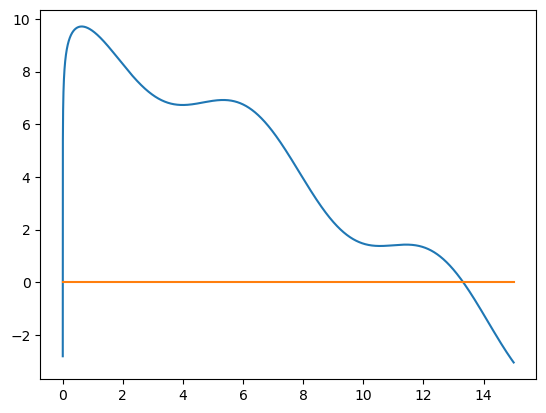

In [12]:
%matplotlib inline
f = lambda x: np.cos(x) + np.log(x)-x + 10
x = np.arange(1e-6,15,1e-6)# interval [1e-6, 15]

# 1) ------ x1,x2 from the plot:
plt.plot(x,f(x))
plt.plot([0,15],[0,0])

# 2) -------x1 by bisection
Biseccion(f,1e-5,.1, 1.0e-10)
# Punto_Fijo(lambda x: np.cos(x) + np.log(x) + 10,1e-3, 1.0e-5)

# 3) -------x1 by fixed point 
Punto_Fijo(lambda x: np.exp(-np.cos(x) + x - 10),1, 1.0e-5) 


### Order of convergence

Suppose the sequence $\{p_n\}_0^\infty$ with $n=0,1,2,...$ converges to $p$; then if

 $$\frac{|p_{n+1} - p|}{| p_n − p|^\alpha} = \lambda,\quad\hbox{ for }\quad n=1,2,...$$

if $\alpha = 1$ the convergence is linear and if $\alpha = 2$ it is quadratic.
The bisection and fixed-point methods have linear convergence, while Newton's and the secant methods have quadratic convergence.


### Taylor series and Taylor polynomial
Suppose $f \in C^n[a, b]$, that $f^{(n+1)}$ exists on $[a,b]$, and $x_0 \in[a, b]$.
Then for each $x$ ∈ $[a, b]$, there exists a number $\xi(x)$ between $x_0$ and $x$ such that:

$$f(x) = P_n(x) + R_n(x)$$

where

$$P_n(x) = f(x_0) + f'(x_0)(x − x_0) + \frac{f''(x_0)}{2!}(x − x_0)^2 +\cdots+\frac{f^{(n)}(x_0)}{n!}(x − x_0)^n$$

and

$$R_n(x) = \frac{f^{(n+1)}(\xi(x))}{(n + 1)!}(x − x_0)^{(n+1)}$$

$P_n(x)$ is the Taylor polynomial and $R_n(x)$ the remainder.
The series is obtained if the sum is taken to infinity.

### Note on the stability of fixed points
Fixed points have countless applications in physics and mathematics;
let's look at the stability of a fixed point $p=g(p)$, such that $p_{n+1}=g(p_n)$; for this consider a small displacement, $\delta p_n=p_n-p$, and by Taylor expansion,

$$p + \delta p_{n+1}=g(p+\delta p_n) =g(p) +g'(p)\delta p_n+ ...$$

which gives,

$$
\delta p_{n+1}= g'(p)\delta p_n + ...
$$

this formula defines stability; let's look at it by analysing the ratio $|\delta p_{n+1}/\delta p_n|= |g'(p)|$ in absolute value:

1. If $|g'(p)|<1$, it means $\delta p_{n+1}$ is smaller than $\delta p_{n}$ and therefore $p$ is stable.

2. If $|g'(p)|>1$, it means $\delta p_{n+1}$ is larger than $\delta p_{n}$ and grows with each iteration, so $p$ is unstable.

3. If $|g'(p)|=1$, then to first order the stability cannot be determined.

Stability has multiple applications in nonlinear dynamics problems, [orbital stability](http://people.uleth.ca/~roussel/nld/stability_maps.pdf), [bifurcations](https://www.aglarick.com/2020/03/05/diagrama-de-bifurcacion/), etc.


**Task**: a) For the function $f(x) = x^3 + 4x^2 − 10 = 0$, plot the function and find the root in the interval $[1, 2]$ by bisection. Answer: $p = 1.365230013$ in 13 steps. b) find the fixed point and the functions $g(x)$ (see Burden p. 61 for the solution).

**Task**: Find the fixed point of $g(x)=\,((3x^4+2x^2+3)/(x^4+4x-1))^{1/2}$ for $p_0=1$. Answer: $p = 1.502022778548$ in 8 steps.

**Task**: show that the functions $g_2, g_3$ and $g_4$ above come from $f(x).$

**Task**: Find the values of $x$ satisfying the equation $\cos(x) + \log(x)= x -10$, using the bisection method and the fixed-point method (hint: first build $f(x)=0$ and plot to know which interval to use). Answer $x_1=1.6701\times10^{-5}$, and $x_2=13.3190$.

**Task**: Find all zeros in the interval $[0,7]$ of the function $f(t)=1/2+\cos(t)+\cos(2t−1/2)/2.$


<a id='Newton-Raphson'></a>
## 4) Newton-Raphson method
Consider the Taylor polynomial up to degree two,

$$f(p) = f(p_0) + (p − p_0)f'(p_0) + \frac{( p − p_0)^2}{2}f''(\xi(p)),$$

since $p$ is a root, $f(p)=0$; solving for $p$ we find,

$$p=p_0-\frac{f(p_0)}{f'(p_0)},$$

with this equation we can define the sequence,

$$p_n=p_{n-1}-\frac{f(p_{n-1})}{f'(p_{n-1})},$$

which converges to the root $p$; this is guaranteed by the following theorem:

**Theorem**: let $f(x)$ belong to $C^2[a,b]$; if $p$ belongs to $(a,b)$ and is such that $f(p) = 0$ and $f'(p) \neq 0$, then there exists a $\delta > 0$ such that the Newton-Raphson method generates a sequence $\{p_n\}_0^\infty$ that converges to $p$ for any initial approximation $p_0$ belonging to the interval $[p - \delta,p + \delta]$.

The following plot shows the Newton-Raphson method for two steps.

|<img src="../figures/Newton_method.png" alt="Drawing" style="width: 600px;"/>|
|:--:| 
| *Figure: Newton-Raphson method for two steps*|

The python implementation is:


In [13]:
import numpy as np

def Newton_Raphson(f,Df,p0,eps=1e-8,Nmax=100):
   
   i=1
   while i<Nmax:
   #while True: # to go with the breaks below
      p = p0 -f(p0)/Df(p0) 
      print (i, p, f(p))  

      if ( np.abs(p - p0) < eps ): break # stopping condition.
      #if ( np.abs((p - p0)/p) < eps ): break
      #if ( np.abs(f(p)) < eps ): break
      i=i+1   
      p0 = p
      
      #if (i == Nmax): print ("the method failed")
   return p         


In [14]:
Newton_Raphson(lambda x: np.cos(x) -x ,lambda x: -np.sin(x) -1,np.pi/4.,1.e-10)
# Result 0.739085133215


1 0.7395361335152383 -0.000754874682502682
2 0.7390851781060102 -7.512986655022758e-08
3 0.739085133215161 -6.661338147750939e-16
4 0.7390851332151606 1.1102230246251565e-16


0.7390851332151606

For the Newton-Raphson method to work you must guarantee $f'(p) \neq 0$; for example the function $f(x) =(x-2)^2 -2$ will have trouble converging to the root if $p_0=2$, since in that case $f'(2)=0$ and the Newton-Raphson method is unable to decide which of the two roots to converge to (see the intersection of the dashed lines with the $x$ axis in the following plot); nevertheless, if a small change is made it does converge (try, for example, $1.999$). In general you should avoid having maxima or minima along the path between $p_0$ and $p$, since $f'(p_n) = 0$ at those extreme points.


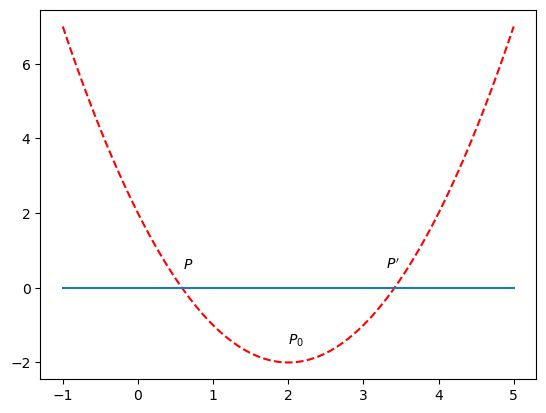

In [15]:
# Cases where Newton's method fails
import matplotlib.pyplot as plt

x = np.linspace(-1,5,10000)
y = (x-2)**2 -2
plt.plot(x,y, 'r--')
plt.plot([-1,5],[0,0])

plt.text(2,-1.5,r"$P_0$")
plt.text(0.6,.5,r"$P$")
plt.text(3.3,.5,r"$P'$")
plt.show()


In [16]:
# Verify that it errors because f'(p) = 0
#Newton_Raphson(lambda x: (x-2)**2 -2,lambda x: 2*(x-2),2,1.e-18) # try p0=1.999, does it converge?


**Exercise**: compare against the fixed-point method and bisection for the same $p_0 = \pi/4.$ 

The Newton-Raphson method has quadratic convergence, which makes it much faster than the bisection and fixed-point methods, which have linear convergence, but it requires knowing the derivative of $f(x)$. In some cases computing the derivative is cumbersome; an alternative is to use an approximation of the derivative, i.e. replace $f'(x)$ by,

$$f'(x)\approx\frac{f(x+h)-f(x)}{h},$$

or even better, use the centred difference since it has lower error,

$$f'(x)\approx\frac{f(x+h)-f(x-h)}{2h},$$


python implementation:


In [17]:
# Newton's method is powerful but requires knowing the analytical derivative, which
# in some cases is cumbersome to compute; one way to avoid the problem is to
# compute the derivative numerically:
def Newton_Raphson2(f,p0,h=1e-5,eps=1e-8,Nmax=100):

   i=1
   while i<Nmax:
      Df = (f(p0+h)-f(p0-h))/(2*h) # Numerical derivative.
      p = p0 -f(p0)/Df 
      print (i, p, f(p))  

      if ( np.abs(p - p0) < eps ): break # stopping condition.

      i=i+1   
      p0 = p
      
      if (i == Nmax): print ("the method failed")
   return p

Newton_Raphson2(lambda x: np.cos(x) -x,np.pi/4.,1.0e-5, 1.e-10)


1 0.7395361335145918 -0.0007548746814204366
2 0.7390851781060045 -7.512985700230956e-08
3 0.7390851332151611 -7.771561172376096e-16
4 0.7390851332151607 0.0


0.7390851332151607

<a id='Metodo_de_la_secante'></a>
## 5) Secant method
The previous method, although it avoids the problem of the analytical derivative, has the problem that
$h$ is constant. In the secant method the derivative is replaced by the approximation,

$$f'(p_{n-1}) \approx \frac{f(p_{n-1}) - f(p_{n-2})}{p_{n-1} - p_{n-2}}.$$
 
 note that in this case $h$ is a function of $n$, i.e. $h = p_{n-1} - p_{n-2}$, so as
 the algorithm converges, $h$ gets smaller.
 Substituting into the Newton-Raphson formula gives,
 
$$p_n = p_{n-1} - \frac{f(p_{n-1})(p_{n-1} - p_{n-2})}{f(p_{n-1}) - f(p_{n-2})}\quad \hbox{ for }\quad n >= 2.$$


In [18]:
def  Secante(f,p0,p1,eps=1e-8,Nmax=100):

   q0 = f(p0)
   q1 = f(p1)
   i = 2
   while i<Nmax:
      p = p1 - q1*(p1 - p0)/(q1 - q0)
      print (i, p, f(p))  
 
      if ( np.abs(p - p1) < eps ): break # stopping condition.
      i = i + 1

      p0 = p1
      q0 = q1
      p1 = p
      q1 = f(p)
      
      if (i == Nmax): print ("the method failed")
   return p
# we use p0 = pi/4 and p1 = 0.5
Secante(lambda x: np.cos(x) -x , 0.5, np.pi/4., 1.e-10)


2 0.7363841388365822 0.0045177185221702
3 0.7390581392138897 4.5177215963754236e-05
4 0.7390851493372764 -2.6982167056210926e-08
5 0.7390851332150645 1.6087131626818518e-13
6 0.7390851332151607 0.0


0.7390851332151607

**Exercise**:
try the numerical version with h = 1.0e-5, 1.0e-3, 1.0e-2, 1.0e-1 and
compare against the secant and Newton methods.

|<img src="../figures/Secant_method.png" alt="Drawing" style="width: 1000px;"/>|
|:--:| 
| *Figure: Convergence of the secant and false-position methods over two steps*|

<a id='Metodo_de_la_posicion_falsa'></a>
# 6) False-position method
Also known as *regula falsi*, it generates approximations in the same
way as the secant method, but includes a test to ensure that
the root is always bracketed between successive iterations,
just as in the bisection method. More precisely, consider two points $p_0$ and $p_1$; then:

  1) If $f(p_0)f(p_1) < 0$ there is at least one root between $p_0$ and $p_1$; then $p_2$ is chosen as the intercept with the $x$ axis of the line joining the points $( p_0, f(p_0))$ and $( p_1, f(p_1))$, hence the name secant method.<br> 
    
  2) Then, if $f(p_2)f(p_1)<0$, $p$ is between $p_1$ and $p_2$; $p_3$ is chosen as the $x$-axis intercept of the line joining the points $( p_1, f(p_1))$ and $( p_2, f(p_2))$.<br>
  
  3) Otherwise (i.e. $f(p_2)f(p_1)>0$), $p_3$ is chosen as the $x$-axis intercept of the line joining the points $( p_0, f(p_0))$ and $( p_2, f(p_2))$, and the indices $p_0$ and $p_1$ are swapped. Finally the cycle repeats for $p_4$, etc.
  
The method converges more slowly than Newton's method and the secant method, but is
faster than bisection and, unlike the secant method (and Newton), it never diverges. Implementation:


In [19]:
def  Regula_falsi(f,p0,p1,eps=1e-8,Nmax=100):

   q0 = f(p0)
   q1 = f(p1)
   i = 2
   while i<Nmax:
      p = p1 - q1*(p1 - p0)/(q1 - q0)
      print (i, p)  
 
      if ( np.abs(p - p1) < eps ): break # stopping condition.
      i = i + 1

      q = f(p)
      
      if (q*q1<0.0):
         p0 = p1
         q0 = q1
      
      p1 = p
      q1 = q
      
      if (i == Nmax): print ("the method failed")
   return p
        
# we use p0 = pi/4 and p1 = 0.5
Regula_falsi(lambda x: np.cos(x) -x , 0.5, np.pi/4., 1.e-10)


2 0.7363841388365822
3 0.7390581392138897
4 0.7390848638147098
5 0.7390851305265789
6 0.7390851331883289
7 0.7390851332148929


0.7390851332148929

<a id='Metodo_de_Steffensen'></a>
## 7) Steffensen's method
Steffensen's method is a variant of the fixed-point method that is accelerated using Aitken's method:


### Accelerating linearly convergent series (Aitken)

Aitken's method states that if a sequence $\{p_n\}_0^\infty$ has linear convergence, it can be replaced by the sequence $\{p_n'\}_0^\infty$ generated by,
 
$$\boxed{p_n' = p_n − \frac{(p_{n+1} - p_n)^2}{p_{n+2} - 2p_{n+1} + p_n}},$$

which converges faster than the original sequence. This technique can be applied to any linearly convergent series.

The derivation starts from the fact that $p$ converges linearly, so,

$$
\frac {p_{n+1} − p}{p_n − p} \approx \frac{p_{n+2} − p}{p_{n+1} − p},
$$

then,

$$( p_{n+1} − p)^2 \approx ( p_{n+2} − p)( p_n − p),$$

after some algebra (see Burden p. 87) we arrive at,

$$p\rightarrow p_n' \approx  p_n − \frac{(p_{n+1} - p_n)^2}{p_{n+2} - 2p_{n+1} + p_n}.$$


If Aitken's method is used together with the fixed-point method, Steffensen's method is obtained, i.e.,
applying Aitken's method to the fixed-point method (which is linear)
gives a new accelerated method with quadratic convergence, provided $g'(p)\neq 1$.
As expected, Steffensen's method is used to find the solution of the equation
$p = g(p)$ given the initial approximation $p_0$.
Let's look at the implementation:


In [20]:
def  Steffensen(g,p0,eps=1e-8,Nmax=100):

   i = 1
   while i<Nmax:
      p1 = g(p0)
      p2 = g(p1)

      p = p0 - (p1 - p0)**2./(p2-2.*p1 + p0)
      print (i, p)  
 
      if ( np.abs(p - p0) < eps ): break # stopping condition.
      i = i + 1

      p0 = p
      
      if (i == Nmax): print ("the method failed")
   return p 
# We use p0 = pi/4 and p0 = 0.5
Steffensen(lambda x: np.cos(x), 0.5, 1.e-10)
#Steffensen(lambda x: np.cos(x), np.pi/4., 1.e-10) # this also converges; try other p0
#                                                   # near the root and note that the
#                                                   # denominator can get close to zero.


1 0.7313851863825818
2 0.7390763403695223
3 0.7390851332036612
4 0.7390851332151607


0.7390851332151607

<a id='Ejercicios'></a>
## Exercises: Physics applications

**Task**: In astronomy the position of a planet in its orbit is given by Kepler's equation, defined by,

$$M=E-e\sin(E)$$

where $E$ is the eccentric anomaly, $M$ is the mean anomaly and $e$ the orbit's eccentricity.<br>
a) Suppose a planet moves on an elliptical orbit with eccentricity $e=10^{-5}$ and anomaly $M=\pi/6$.<br>
b) Plot $E$ for $M=\pi/6$ and $10^{-5}<e \leq 2.0$ (use steps of $\Delta e=0.001$); check in which situations you can use the fixed-point method and in which Newton-Raphson.<br>
c) Plot $E$ for $e=10^{-5}$ and $0\leq M\leq \pi$.

<!---
see
http://www.csun.edu/~hcmth017/master/node16.html
--->


**Task**: In pipe hydraulics there is a transcendental equation that lets you obtain the maximum flow a circular pipe can carry for a fixed slope, obtaining the optimal depth for the maximum hydraulic radius. For this, the numerical solution of the transcendental equation is used,

$$\alpha =\tan(\alpha)$$

This equation admits infinitely many solutions; the smallest strictly positive solution is given by the value $\alpha =4.493409$ (usually interpreted as the value in radians of an angle). Other solutions are: $\alpha =7.7252, 10.9042, 14.0661, 17.2208,\dots$.

For large values of n there are solutions close to $(2n+1)\pi /2$. Also, if $\alpha =\beta$ is a solution then $\alpha =-\beta$ is also a solution. All solutions have simple multiplicity except $\alpha =0$, which has multiplicity 2.

**Task**: the [Lambert W function](https://en.wikipedia.org/wiki/Lambert_W_function) (named after Johann Heinrich Lambert) has applications in thermodynamics such as computing entropy; it is defined as the inverse function $W(z)$ such that,

$$
z=W(z)e^{W(z)},
$$

for every complex number $z$, i.e.:

$$
z=Ye^{Y}\;\Longleftrightarrow \;Y=W(z).
$$

Implement the Lambert W function in python using the Newton-Raphson method for any value of $z$ (use as the initial approximation $p_0=\log(z)$. Keep in mind that $W(x)$ is real for $x\geq -1/e, W(0)=0,$ also $W(1/e)=-1$ and $W(1)=0.567143...$ ).

**Task**: In general, the transcendental equation

$$e^{cx}=ax+b$$

(or its equivalent $cx=\ln(ax+b)$) has a unique solution that can be expressed in terms of the Lambert W function:

$$ x =-{\frac {1}{c}}W\left(-{\frac {c}{a}}e^{-{\frac {bc}{a}}}\right)-{\frac {b}{a}}.$$

More generally,

$$p^{ax+b}=cx+d \quad\Longleftrightarrow\quad x=-{\frac {W\left(-{\frac {a\ln p}{c}}\,p^{b-{\frac {ad}{c}}}\right)}{a\ln p}}-{\frac {d}{c}}$$ 

where $p>0\land c,d\neq 0$.

Compare the analytical solution to the Newton-Raphson method. Hint: in python the [Lambert W function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.lambertw.html) is given by,
```python
from scipy.special import lambertw

x = lambertw(z)
```
    


**Task**: Plans are being made for an antenna using a rod of length $l$, located along the $x$ axis and carrying a net charge $Q$. It can be shown that the potential at a point with coordinates $P = (0,d)$ is given by

$$V=  \frac{kQ}{l} \ln⁡\left(\frac{l+\sqrt{l^2+d^2}}{d}\right)$$

1. Plot the function $f(l)=0$ — how many roots are there? (use `l = np.arange(0, 2.0, 0.001))`.
Give an approximate value from the plot.
2. Using the secant method, compute the length of the rod that produces a potential of $0.5$ V at a distance $d=0.3$ m (use $kQ=1$).
3. Using a $p_0$ of your choosing, how many iterations are needed to find the frequency with an error smaller than $10^{-8}$?
4. Choose an interval $(a,b)$ and confirm your result using the bisection method — how many iterations are needed to find the length with an error smaller than $10^{-5}$?

<!---
Solution: 
$$l=  \frac{kQ}{V} \ln⁡\left(\frac{l+\sqrt{l^2+d^2}}{d}\right)$$
which defines the fixed-point equation $l=g(l)$ or also the root problem,

$$f(l) = l - \frac{kQ}{V} \ln⁡\left(\frac{l+\sqrt{l^2+d^2}}{d}\right)=0,$$

[see](http://hyperphysics.phy-astr.gsu.edu/hbase/electric/potlin.html) or
[see met doc, page 31](http://web.mit.edu/8.02t/www/802TEAL3D/visualizations/coursenotes/modules/guide03.pdf)
--->


**Task**: It's known that in damped motion the energy decreases over time due to a dissipative force proportional to the velocity, with proportionality constant $b= 0.1$ kg/s; but if a restoring force $F_0=0.4$ N is introduced, the motion becomes simple harmonic again and can be shown to be governed by the equation:

$$x=\frac{F_0/m}{\sqrt{(\omega^2-\omega_0^2)^2+\left(\frac{b\omega}{m}\right)^2 }} \cos⁡(\omega t+\delta)$$

1. Build and plot the function $f(\omega)$ — how many roots are there? Consider $t=1$ s, $x=0.1$ m, $m=0.2$ kg, $\delta=0.0$ and  $\omega_0=2.4$ Hz (use `ω = np.arange(0, 20, 0.001)`).
2. Using Newton's method (you may use the numerical derivative), compute the frequency $\omega$.
3. Using a $p_0$ of your choosing, how many iterations are needed to find the frequency with an error smaller than $10^{-8}$?
4. Choose an interval $(a,b)$ and confirm your result using the bisection method — how many iterations are needed to find the frequency with an error smaller than $10^{-5}$?



**Task**: Consider a spring with one end attached to a wall and a constant force of 2N applied to the other end; if the spring opposes a resistance force to deformation given by $F=k(x)x=\exp(x)x$, a) compute the value at which the forces balance. b) suppose the spring has a weight $W=1$ kg, compute the equilibrium distances $(x,y)$.

**Task**: The Shockley equation describes the behaviour of a diode connected to a generator; if the current in the diode is given by $I = I_0(\exp (V/V_T) - 1)$ (where $V_T=K_BT/q_e$ is the thermal voltage, $T$ the temperature, $K_B$ the Boltzmann constant and $e$ the electron charge), the voltage is $V = v - IR$ (since the generator has an internal resistance $R$ and a nominal voltage $v$); moreover, since $I = (v - V)/R$, we get the relation,

$$(v - V) = R I_0 (\exp(V/V_T) - 1).$$

a) Find the values $(I,V)$ for $R=2k\Omega$, $RI_0= 0.1$ fA, $v= 1$V and $K_B/q_e = 8.6173333\times10^{-5}$ V/K (try other values).<br>
b) Plot $(I(T),V(T))$ for $0<T<100$ K.


<!---
1) In electricity Shockley diode equation describes a diode  connected to a generator.
The diode lets current i = i_0 (exp (V / V0) - 1).  (Note: In introductory courses you probably see that a diode lets i=0 for V < V0 and whatever current for V = V0.)    We also know that the voltage is V = v - ri (the generator has internal resistance r, so that the voltage is a bit smaller than nominal voltage v).  Thus i = (v - V) / r so that we get the equation:

$$(v - V) = r i_0 (\exp(V/V0) - 1). $$ 
see also: 
https://qucs.github.io/tech/node16.html
https://www.ele.uri.edu/courses/ele338/summer2020/DiodeModels.pdf
--->        
 **Task**: The value of the average magnetization in a magnet according to mean-field theory is given by the equation,
 
$$M=\tanh((JM+B)/K_BT),$$

where $J$ is a coupling constant, $B$ is an external magnetic field applied to the magnet, $T$ the temperature and $k$ the Boltzmann constant. <br>
a) For $B=0$ plot $M/J$ as a function of temperature to see the phase transitions — at what value does the critical Curie temperature occur, i.e. the value $T_c$ for which $M(T_c)=0.0$? assume $K_B=1$ for simplicity.<br>
b) Repeat the plot for different positive and negative values of $B$.

<!--- 
**Tarea**:  The expected spin using mean field theory in the Ising model. For spin σ between negative one and one, external magnetic field B, spin coupling J, and temperature T
, we have:
⟨σ⟩=tanh((J⟨σ⟩+B)/kT)

If we plot this for different temperatures, you'll see exactly how the phase transition happens. It has one solution for high temperatures but three (with one solution unstable) for low temperatures.

**Task**: Consider the equation describing the behaviour of waves on a guitar string with ends fixed at $x=0$ and $x=L$,

$$\sin(kx)=\sin(k(L−x)),$$

the obvious solutions are $x=0$ and $x=L$, but others exist — find all possible values of $k$ satisfying this equation.


**Tarea**:  sin(kx1)=sin(k(L−x1))(1).
The first sin is a solution turning into zero at x=0, the second one turns into zero at x=L. This is a solution for an elastic guitare string fixed at x=0 and x=L. At x=x1 we require continuity of the total solution; thus the equation (1). We must find the possible values of k_n to satisfy this equation.
--->
**Task**: magnetic resonance imaging is a widely used technique in biomedical applications: to produce images at a point, a solenoid of radius $a$ and length $l$ is used, which produces a flux density that depends on the number of turns $N$, the current $I$ and the permeability of space $\mu_0=4\pi\times10^{-7}$ H/m. If the inductance $L$ (in Henries) is given by,

$$
L=\frac{\mu_0N^2\pi a^2}{l^2}\left(\sqrt{l^2+a^2}-a\right).
$$

a) Find the radius $a$ of the solenoid that is capable of producing an inductance of $2.6 \mu H$ if $N=10$ and $l=10$ cm; for this compare Newton-Raphson (or one of its variants) and the fixed-point method. What do you conclude?<br>
b) Plot $a$ as a function of $N$.

<!---
### Another interesting problem: Driven harmonic oscillators (falta....)
This equation can be solved exactly for any driving force, using the solutions z(t) that satisfy the unforced equation

 $${\frac {\mathrm {d} ^{2}z}{\mathrm {d} t^{2}}}+2\zeta \omega _{0}{\frac {\mathrm {d} z}{\mathrm {d} t}}+\omega _{0}^{2}z=0,$$

and which can be expressed as damped sinusoidal oscillations:

$${\displaystyle z(t)=A\mathrm {e} ^{-\zeta \omega _{0}t}\sin \left({\sqrt {1-\zeta ^{2}}}\omega _{0}t+\varphi \right),}$$

in the case where ζ ≤ 1. The amplitude A and phase φ determine the behavior needed to match the initial conditions. 

[from: wiki Driven_harmonic_oscillators](https://en.wikipedia.org/wiki/Harmonic_oscillator#Driven_harmonic_oscillators).

Mas problemas: [link](https://nptel.ac.in/courses/122104019/numerical-analysis/Rathish-kumar/ratish-1/f3node1.html)

https://aip.scitation.org/doi/full/10.1063/1.4902161?crawler=true&

--->


**Task**: Two charges $q=1$ and $Q=1.2$, with masses $m_1=1$ and $m_2=1.5$ units, interact via the Coulomb potential,
$$E_p = k\frac{Qq}{r},$$ 
(take $k=1$) if the charges start at rest, separated by $r_0=0.5$ units, and are allowed to interact, compute and plot the coordinates and velocities as functions of time (hint: consider the reference frame on one of the charges and use conservation of energy; note $0< r_0\leq r$).


**Task**: In 1919 Einstein became an international celebrity for the confirmation of his general theory of relativity thanks to the British experimental work of Eddington on the deflection of light passing through a gravitational field such as the sun's. It can be shown that the deflection $\phi$ of light is given by,

$$
y=\frac{1}{r}\left(1-\frac{M}{r}\right)\\
\phi=\frac{2M}{b}+\arcsin(by)-2M\left(b^{-2}-y^2\right)^{1/2},
$$

where $r$ is the distance from the light ray to the body of mass $M$ (the sun's mass) and $b$ is the impact parameter (i.e. the minimum distance at which the ray would pass the sun if there were no deflection).<br>
a) Compute the impact parameter as a function of the angle $\phi$; consider the mass in fractions of the sun's mass $M=1$ (solar units) and $r=2$ units.<br>
b) If a light ray is deflected $0.05^\circ$ passing at a minimum distance of $r=1.2$ units from a star, what is the star's mass? (consider $b=1.5$.)
<!---
Ver libro: A First Course in General Relativity
Second Edition Bernard F. Schutz, pag 294.
--->

**Task**: In [quantum spectroscopy](https://doi.org/10.1515/astro-2017-0001) it's proposed to compute the area of a black hole using the formula $A=4\pi r^2_h$, where $r_h$ is the event horizon radius, computed from,

$$
r_h=2M\left[1 -\frac{2M}{\sqrt{\pi\theta}}\exp\left(-\frac{M^2}{\theta}\right)\right],
$$

where $\theta$ is a parameter (assume $\theta= 1.0$ for simplicity).<br>
a) Compute the black hole's mass $M$ as a function of the black hole's radius.<br>
b) Plot the mass and the area as functions of the radius.  

<!---
ver: ChengZhou Liu, and HaiWen LiuBlack hole spectroscopy via an action invariance in noncommutative spacetime, Open Astron. 2017; 26: 18–2.
--->

**Task**: [Building fractals](http://usefuljs.net/fractals/docs/newtonian_fractals.html), if instead of the reals we consider complex numbers, starting from the initial conditions $z_0=x_0+y_0j$, fractal figures can be created; consider the function,

$$
f(z)= z^3 - 1 = 0,
$$

Plot imag($z$) vs real($z$), considering the initial conditions $z_0=1, z'_0=0.5+\sin(2\pi/3)j$ and $z''_0=0.5-\sin(2\pi/3)j$.

You can also consider:

$$
\begin{align}
b) f(z)=\,& z^3 - z^2 - z + 1 = 0,\\
c) f(z)=\,& z^4 - 1 = 0,\\
d) f(z)=\,& z^3 - 1; z_0 = 2,\\
\end{align}
$$


More on fractals and Newton-Raphson:<br>
https://www.mitchr.me/SS/newton/ <br>
https://computingskillset.com/solving-equations/newton-fractals-explained-examples-and-python-code/


<!---
**Tarea**: Difracción de Fraunhofer por una regilla
http://www.iiserpune.ac.in/~rejish/assets/files/Optics_Lec4n.pdf
http://www.physics.louisville.edu/sbmendes/phys%20356%20fall%2016/Fraunhofer%20Diffraction.pdf
--->


**Task**: Halley's method is a root-finding algorithm useful for real-variable functions with a continuous second derivative, and widely used in astronomy (discovered by the English mathematician Edmond Halley); it is defined by,

$$
x_{n+1}=x_{n}-{\frac {f(x_{n})}{f'(x_{n})-{\frac {f(x_{n})}{f'(x_{n})}}{\frac {f''(x_{n})}{2}}}}=x_{n}-{\frac {f(x_{n})}{f'(x_{n})}}\left[1-{\frac {f(x_{n})}{f'(x_{n})}}{\frac {f''(x_{n})}{2f'(x_{n})}}\right]^{-1}
$$

with cubic convergence given by,

$$
|x_{{n+1}}-a|\leq K{|x_{n}-a|}^{3},{\text{ for }}K>0.
$$

Implement the algorithm in python.

**Task**: There are different methods to estimate the physical properties of discovered planets.
If a planet's mass is known, an approximate way to estimate its radius is to assume a certain homogeneous mass distribution (a very bad assumption!). For example, suppose the planet [Gliese 832c](https://en.wikipedia.org/wiki/Gliese_832_c), with mass $M = 5.40 M_{t}$, has a composition similar to Earth's (which has mass $M_{t}$, with density $\bar \rho_{t} = 5520\ kg/m^3$); we obtain:

$$R_{g832c} = \left( \frac{3 M_{g832c}}{ 4 \pi \bar\rho_{t} } \right)^{1/3} \approx 1.75 R_{t}$$

which would be the planet's radius if its composition were exactly the same as Earth's. A more realistic approach is to assume an internal density profile such as,

$$\rho(r) = \rho_0 \exp\left( -\frac{r}{L} \right)$$

where $ \rho_0 $ is the density at the planet's centre and $ L $ is a characteristic length that depends on composition. From numerical models of planetary interiors, the estimated parameters for a planet are $M= 5.40 M_{t}$, $\rho_0 = 18000\ kg/m^3$ and $L = 6500\ km$. Integrating over the planet's volume, the total mass can be obtained as,

$$M(R) = 4\pi \int_0^R \rho(r)r^2dr,$$

which is a function of the mass $M(R) = M_{g832c}$ in terms of the planet's radius $R$. Solve the integral and find the radius of *Gliese 832c* using the fixed-point and Newton-Raphson methods.

**Task**: It's known that light rays bend when they pass near a gravitational field, and that this deflection is proportional to the mass of the body the light interacts with and inversely proportional to the passing distance. Since it's common to find very massive structures in the universe, and the measurements taken to study them involve photons, it makes sense to study what happens to a light-source image when the rays pass close to a massive object such as a dark-matter halo. To study the deflection of light in these cases, the simplest model will be used, gravitational lensing theory, where the lens is a very massive object. The following figure shows a schematic of a typical system. The source plane is the light source or image that will be affected; $\eta$ is the distance from a point in the image to the line of sight and $ \beta$ the angle subtended by the point.
The lens plane corresponds to the mass affecting the light coming from the source; $ \xi $ is the new distance from the image point to the line of sight, $ \theta $ is the angle subtended by the new position of the point. Then $ \alpha $ is the deflection angle.

Since $ \theta $ is known from observations, the problem to solve per pixel is usually

$$
\begin{equation}
\beta = \theta - \hat{\alpha}(\theta) 
\end{equation}
$$

but $ \alpha $ also depends on $ \theta $ in addition to the properties of the halo lens that allows a real image to be created from the distorted one.

<img src="../figures/lente1.png">

or equivalently, in terms of the distances,

$$
\begin{equation}
\vec{\eta}  = \frac{D_s}{D_d} \vec{\xi} - D_{ds}\alpha ( \vec{\xi }) 
\end{equation}
$$

The solution to the lens equation is easier to obtain if the lens is assumed to be axially symmetric. In this case, the deflection angle takes the following form,


$$ \hat{\alpha}(\vec{\xi}) = \frac{\vec{\xi}}{|\vec{\xi}|^2} \frac{8G\pi}{c^2} \int_0^\xi d\xi'\xi'\Sigma(\xi')$$

The quantity $\Sigma$ is the surface mass density, i.e. the mass per unit area of the lens enclosed within the circle of radius $\xi$. It's important to note that the direction of $\alpha$ is the same as $\xi$ and, consequently, $\eta$. Given the positions of a square grid, find the distortion of the image due to gravitational lensing, i.e. find the root of $\xi$ in the transcendental equation. Use the routines given below along with all the lens and image data to be distorted.


In [21]:
from scipy import integrate  # needed for integrate.quad used below

#Superficial density of the lens
def Sup_density(radio):
    return radio*M*len(r[r<radio])/radio**2.

#Deviation angle due to the gravitational lens
def des_angle( radio ):
    return 2*np.pi*4*G*integrate.quad( Sup_density ,0, radio )[0]/(radio*c**2)

#Lens equation
def Len_equation(radio, eta):
    return eta - Ds*radio/Dd - Dds*des_angle( radio )


In [22]:
# Lens distribution generated 
M = 3e7
L = 1e5
puntos = 6
Ds = 1000
Dd = 900
Dds = Ds - Dd
G = 4.302e-3# pc M_sun**-1(km/s)**2
c = 3e6 # km/s 
x = np.linspace(0,L,puntos)
y = np.linspace(0,L,puntos)
X,Y = np.meshgrid(x,y)
#Generating meshgrid of points 
X = np.reshape(X,puntos*puntos)
Y = np.reshape(Y,puntos*puntos)
r = np.sqrt(X**2 + Y**2)

#Image to be distorted
Li = 5
ni = 8
X0 = np.linspace(-Li,Li,ni)
Y0 = np.linspace(-Li,Li,ni)
#Generating meshgrid of points 
X0,Y0 = np.meshgrid(X0,Y0)
r0 = np.sqrt( X0**2 + Y0**2 )
theta = np.zeros((ni,ni))
epsilon = np.zeros((ni,ni))

# TODO (exercise): for each grid point (X0[i,j], Y0[i,j]) with eta = r0[i,j],
# solve Len_equation(radio, eta) = 0 for radio (e.g. with Newton_Raphson2 or
# Biseccion), then set theta[i,j] = np.arctan2(Y0[i,j], X0[i,j]) and
# epsilon[i,j] = radio. Only after this loop is filled in will the plot
# below show the actual lensed image instead of a single point at the origin.


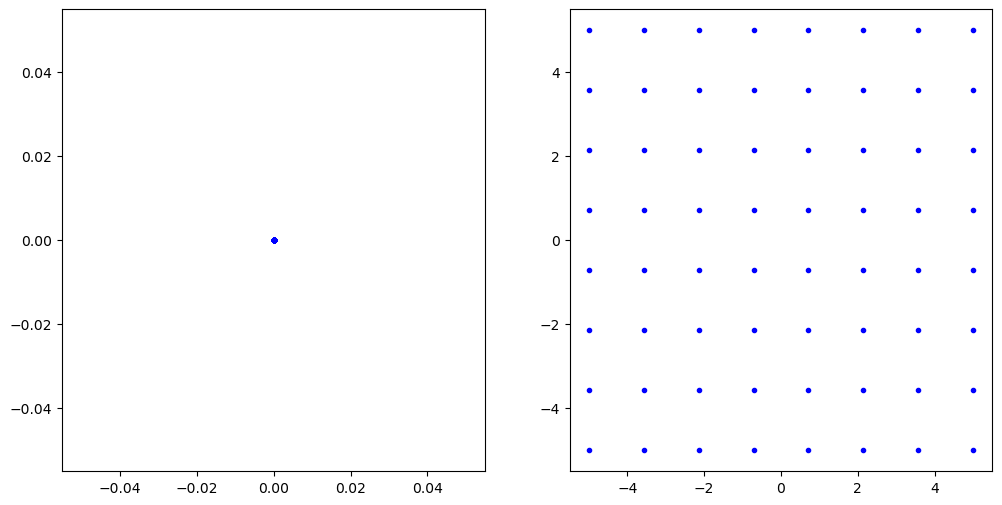

In [23]:
xc = epsilon*np.cos(theta)
yc = epsilon*np.sin(theta)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(xc,yc,'b.');
plt.subplot(1,2,2)
plt.plot(X0,Y0,"b.");


<a id='Material_complementario'></a>
# Supplementary material

### Forward difference
defined as

$$∆p_n = p_{n+1} - p_n, \quad \text{for}\quad n >= 0.$$

for power 2

$$
∆^2p_n = ∆(p_{n+1} − p_n)
       = p_{n+2} -2p_{n+1} +p_n,
$$

for higher powers

$$
∆^kp_n = ∆(∆^{k-1}p_n), \quad \text{for}\quad k \le 2.
$$

###  Backward difference
defined as:

$$ ∇p_n = p_n - p_{n−1}, \quad \text{for}\quad  n ≥ 1.$$

for higher powers

$$∇^kp_n = ∇(∇^{k−1}p_n), \quad \text{for}\quad  k \le 2.$$
